# Human Activity Recognition with Wifi

In [8]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from models.SHARP import *
from utilities.training import *
from utilities.plotting import *

from time import time 
from torchvision.transforms import Compose, ToTensor, RandomHorizontalFlip, RandomVerticalFlip
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from glob import glob
from tqdm import tqdm

%load_ext autoreload
%autoreload 2


###############  GLOBAL VARIABLES  #################
DEBUG_MODE                 = True

PERFORM_DATASET_SEPARATION = True
DATASET_PATH               = "doppler_traces/S2*"
TEST_DATASET_FRACTION      = 1
DOPPLER_TRACE_SIZE         = 340
ACTIVITIES                 = ['W', 'E', 'R', 'J', 'L']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [ ]:
'''
    We split each Doppler trace in DATASET_PATH into several Doppler sub-traces of size DOPPLER_TRACE_SIZE,
    then we randomly split each collection of sub-traces into a train/test dataset folder.
'''

train_dataset = DATASET_PATH.split('/')[0] + "_train"
test_dataset  = DATASET_PATH.split('/')[0] + "_test"
if PERFORM_DATASET_SEPARATION and (train_dataset not in listdir()) and (test_dataset not in listdir()):
    subdir_list = sorted([name for name in glob(DATASET_PATH) if path.isdir(name)])

    # Counting number of images in DATASET_PATH
    traces_number = 0
    for subdir in subdir_list:
        traces_number += len(glob(subdir))
    print(f"Dataset {DATASET_PATH} contains {traces_number} traces.\nProceding to create training dataset with {int((1-TEST_DATASET_FRACTION)*traces_number)} traces and test dataset with {int(TEST_DATASET_FRACTION*traces_number)} traces...\n")

    # Creating train and test datasets
    makedirs(train_dataset, exist_ok=True)
    makedirs(test_dataset, exist_ok=True)

    # Splitting a trace in many sub-traces and randomly assigning them to train/test dataset
    for subdir in subdir_list:
        for trace_name in sorted(listdir(subdir)):
            # Only traces whose label is in ACTIVITIES are used for training/testing
            if trace_name.split('_')[1][0] in ACTIVITIES:
                trace_path = subdir+'/'+trace_name
                full_trace = np.load(trace_path, allow_pickle=True)
                N_images = full_trace.shape[0]//DOPPLER_TRACE_SIZE

                for i in range(N_images):
                    # Name of sub-trace is the one the original full trace + an index to distinguish
                    if rnd.uniform()<TEST_DATASET_FRACTION:
                        np.save(test_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)
                    else:
                        np.save(train_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)

    print("Train and test datasets created successfully!")
else:
    print("Datasets are already splitted!")

Datasets are already splitted!


## Loading Dataset

In [3]:
transforms = Compose([
    RandomVerticalFlip(),
    RandomHorizontalFlip()
])

Loading dataset doppler_traces_train in memory...


2253it [00:01, 2066.96it/s]


Dataset is loaded!
Loading dataset doppler_traces_test in memory...


1003it [00:00, 2171.50it/s]


Dataset is loaded!


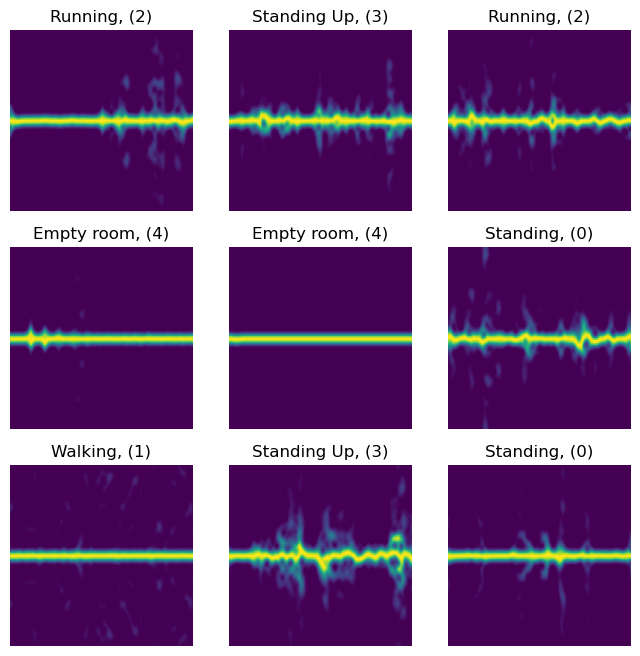

In [ ]:
batch_size = 128
train_dataset  = DopplerDataset("doppler_traces_train", ACTIVITIES)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset  = DopplerDataset("doppler_traces_test", ACTIVITIES)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)

labels_map = {
    0: "Standing",
    1: "Walking",
    2: "Running",
    3: "Standing Up",
    4: "Empty room",
    5: "Sitting",
    6: "Moving arm",
    7: "Jumping"
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(f"{labels_map[int(label)]}, ({label})")
    plt.axis("off")
    plt.imshow(img[0,:,:], aspect='auto')
plt.show()

## Training of SHARP architecure

In [12]:
sharp_model = SHARP(n_features=len(ACTIVITIES))

learning_rate = 1e-4
device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate)

if DEBUG_MODE:
    #### CHECKING DATA TYPES 
    x, y = next(iter(train_dataloader))
    print(x.dtype)
    print(next(sharp_model.parameters()).dtype)
    ### DEVICE
    print(f"Device: {device}")

torch.float32
torch.float32
Device: mps


In [13]:
epochs = 20
train_loss, test_loss, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/20 ------ Time (total): 0.00 ------ Time (relative): 0.00

tensor([0, 3, 0, 2, 2, 1, 1, 4, 2, 0, 2, 0, 0, 2, 4, 4, 2, 1, 4, 0, 2, 1, 0, 4,
        1, 1, 4, 3, 1, 3, 4, 3, 4, 3, 2, 0, 2, 2, 3, 4, 2, 4, 0, 2, 2, 0, 4, 0,
        1, 3, 4, 1, 0, 2, 1, 0, 4, 1, 1, 4, 2, 2, 1, 1, 0, 3, 3, 2, 4, 3, 1, 3,
        2, 1, 4, 3, 1, 4, 0, 0, 3, 2, 4, 2, 2, 3, 2, 4, 1, 3, 3, 2, 4, 3, 2, 2,
        3, 0, 1, 1, 0, 4, 1, 2, 1, 2, 0, 0, 1, 0, 2, 3, 2, 0, 3, 4, 2, 0, 3, 0,
        2, 2, 2, 4, 0, 4, 4, 1], device='mps:0')
Loss: 1.61391e+00 --- Samples:   128/ 2253
tensor([4, 0, 2, 2, 1, 2, 0, 4, 0, 0, 1, 3, 4, 0, 3, 0, 2, 0, 0, 4, 1, 0, 2, 3,
        3, 3, 1, 1, 0, 1, 4, 0, 4, 3, 1, 3, 2, 3, 1, 0, 1, 3, 4, 4, 2, 3, 4, 0,
        4, 1, 1, 3, 3, 4, 2, 0, 4, 0, 1, 3, 0, 3, 3, 0, 4, 2, 2, 3, 4, 2, 1, 2,
        0, 3, 4, 1, 2, 3, 3, 2, 3, 1, 1, 1, 3, 3, 3, 3, 2, 4, 1, 1, 1, 2, 4, 1,
        2, 1, 4, 2, 2, 4, 1, 1, 3, 1, 1, 2, 4, 1, 0, 2, 4, 3, 4, 0, 1, 0, 0, 2,
  

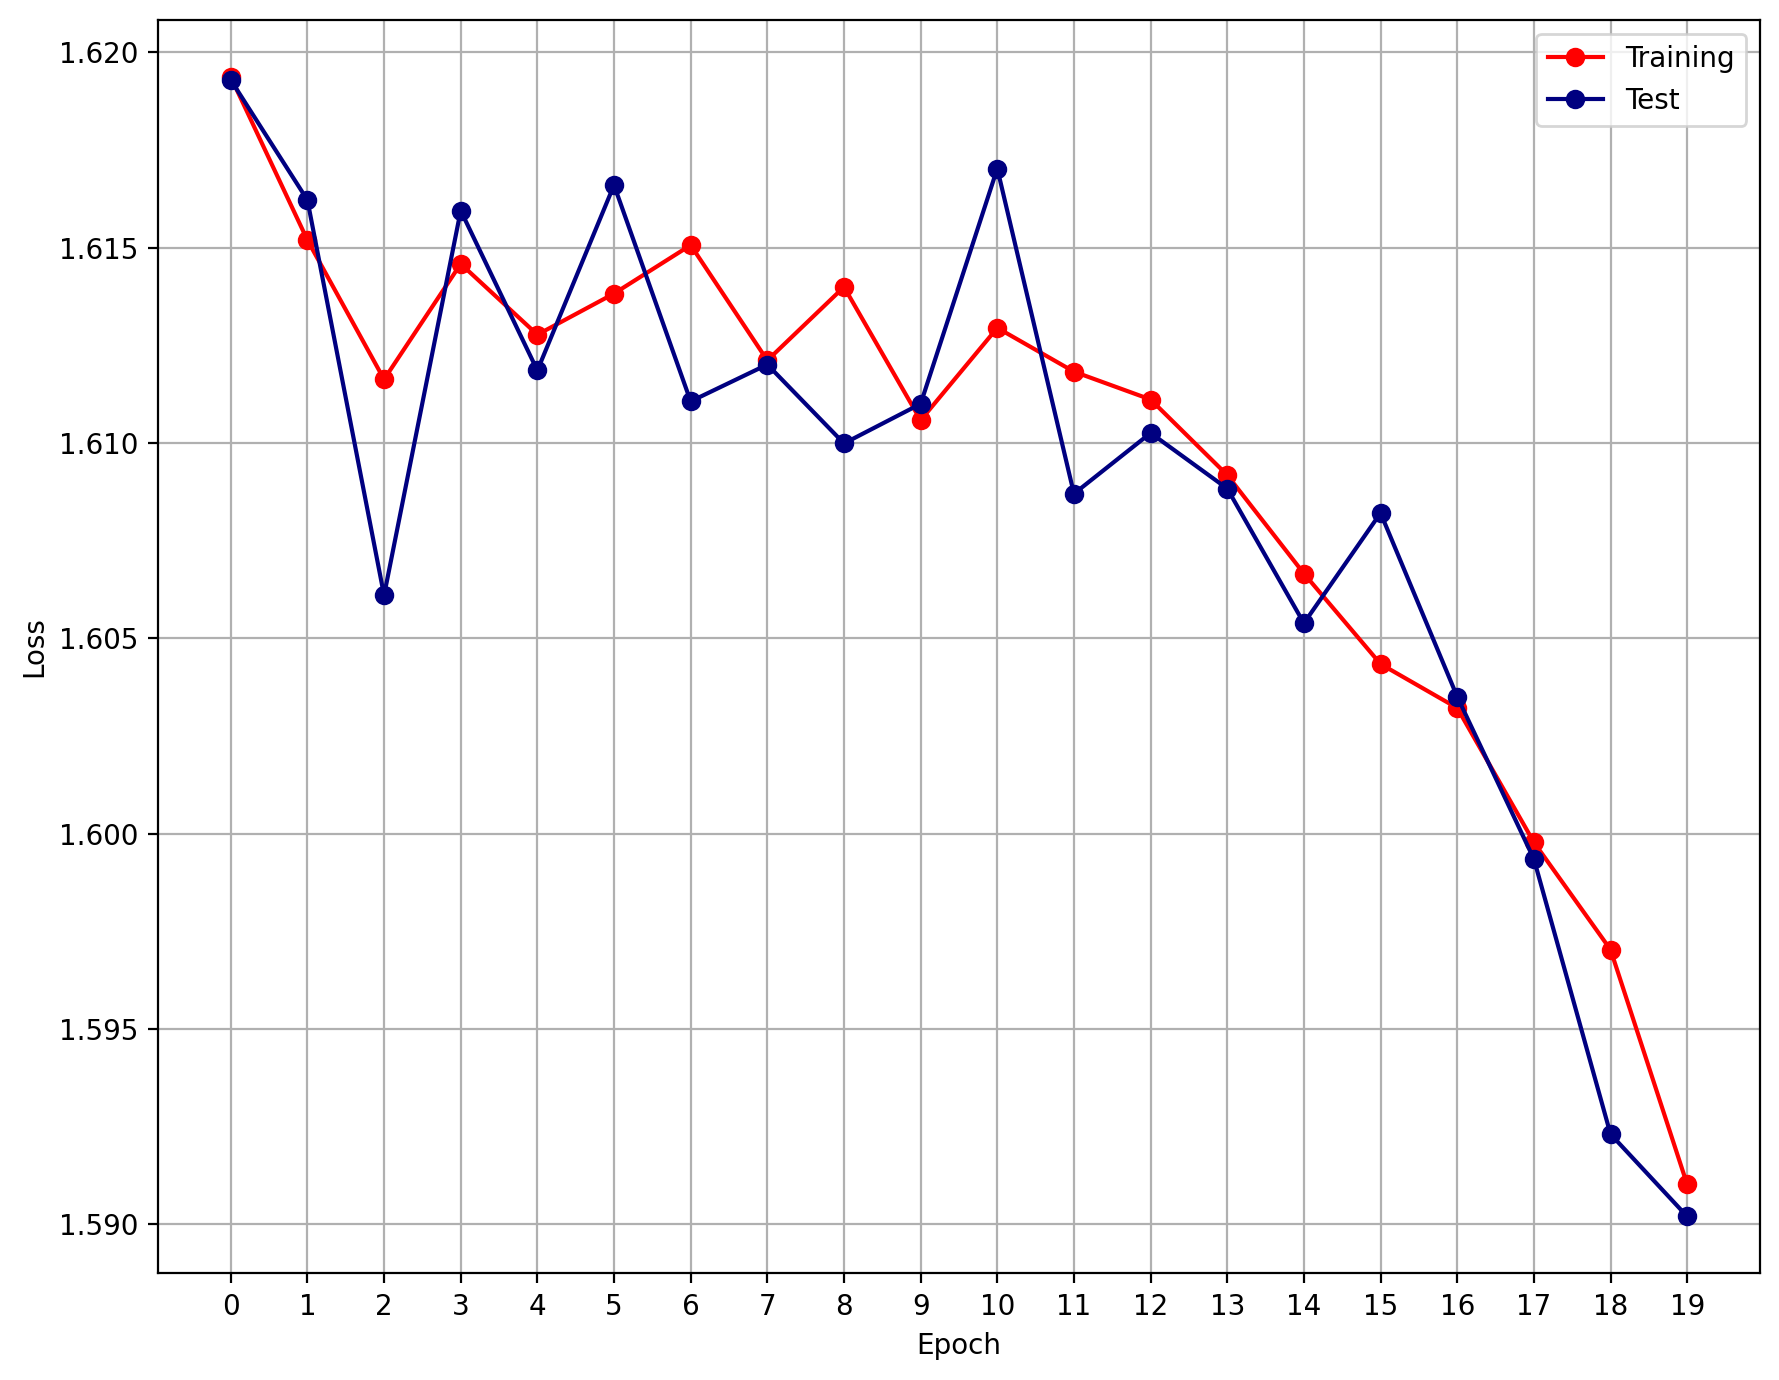

In [14]:
plot_loss(train_loss, test_loss)